# Graph Neural Networks — Node Classification on Cora

**Author:** Shivani Bokka
**Dataset:** Cora citation network (2,708 papers, 5,429 citation links, 7 topics)
**Goal:** Build a Graph Convolutional Network (GCN) and classify nodes in a graph — data that doesn't fit the grid (images) or sequence (text) shape every other notebook assumed.

---

## What Is This Notebook About?

Every previous notebook assumed a fixed structure: MLPs took **flat vectors** (nb 01), CNNs took **grids** (nb 02), RNNs and Transformers took **sequences** (nb 03–04). But enormous amounts of real data are **graphs** — social networks, molecules, road maps, citation networks, recommendation systems. Graphs have no fixed size and no natural ordering, so none of the earlier architectures apply directly.

**Graph Neural Networks** generalize deep learning to this setting. We build a **Graph Convolutional Network** and use it for **node classification**: given a citation network where each node is a paper described by its word contents, predict each paper's topic — using not just the paper's own words but the words of the papers it cites.

---

## The One-Sentence Idea

> **Each node updates its representation by averaging in the representations of its neighbors — stack a few of these "message-passing" layers and information flows across the graph.**

---

## Topics Covered

| # | Section | Key Idea |
|---|---------|----------|
| 1 | Imports and Setup | PyTorch Geometric, seeds, device |
| 2 | The Cora Graph | Nodes, edges, features, train/test masks |
| 3 | Message Passing | The core GNN operation, in plain language |
| 4 | The GCN Model | Two graph-convolution layers |
| 5 | Training | Semi-supervised node classification |
| 6 | Does the Graph Help? | GCN vs a graph-blind MLP |
| 7 | Embedding Visualization | t-SNE of learned node representations |
| 8 | Key Takeaways | Where GNNs fit |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

plt.rcParams['figure.figsize'] = (10, 5)
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
import torch_geometric
print(f"PyG version     : {torch_geometric.__version__}")
print(f"Device          : {device}")


PyTorch version : 2.5.1+cu121
PyG version     : 2.7.0
Device          : cuda




---
## Section 2 — The Cora Graph

**Cora** is the "MNIST of graph learning." Each of the 2,708 nodes is a machine-learning paper; an edge means one paper cites another. Each node has a **1,433-dimensional bag-of-words** feature vector (which of 1,433 keywords appear), and belongs to one of **7 topics** (e.g. Reinforcement Learning, Neural Networks, Theory).

It's **semi-supervised**: only a handful of nodes per class are labeled for training (140 total), and we predict the rest — a realistic setting where labels are scarce but the graph structure is fully known.


Processing...


Done!


Nodes            : 2708
Edges            : 10556
Features/node    : 1433
Classes          : 7
Training nodes   : 140
Validation nodes : 500
Test nodes       : 1000


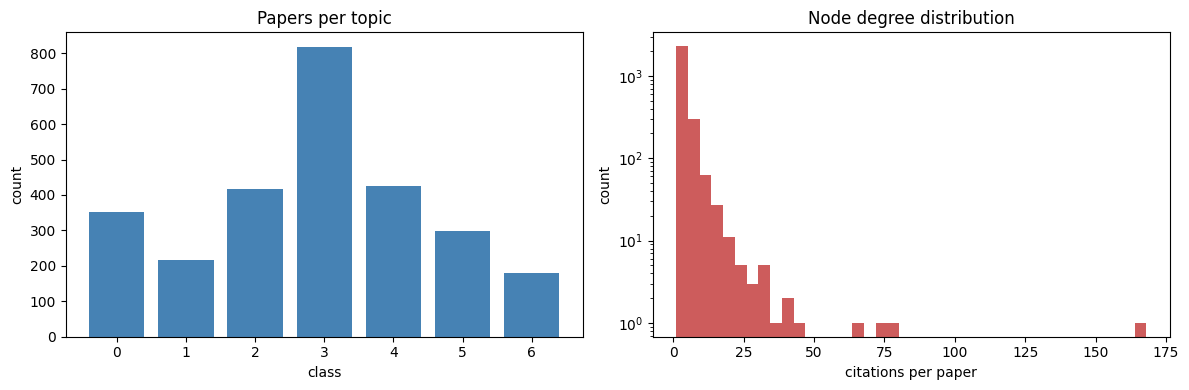

In [2]:
dataset = Planetoid(root='data/Cora', name='Cora')
data = dataset[0].to(device)

print(f"Nodes            : {data.num_nodes}")
print(f"Edges            : {data.num_edges}")
print(f"Features/node    : {dataset.num_node_features}")
print(f"Classes          : {dataset.num_classes}")
print(f"Training nodes   : {int(data.train_mask.sum())}")
print(f"Validation nodes : {int(data.val_mask.sum())}")
print(f"Test nodes       : {int(data.test_mask.sum())}")

# Class distribution and node-degree distribution
deg = torch.zeros(data.num_nodes, device=device)
deg.index_add_(0, data.edge_index[0], torch.ones(data.edge_index.size(1), device=device))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cls_counts = torch.bincount(data.y.cpu())
ax[0].bar(range(dataset.num_classes), cls_counts.numpy(), color='steelblue')
ax[0].set_title('Papers per topic'); ax[0].set_xlabel('class'); ax[0].set_ylabel('count')
ax[1].hist(deg.cpu().numpy(), bins=40, color='indianred')
ax[1].set_title('Node degree distribution'); ax[1].set_xlabel('citations per paper'); ax[1].set_ylabel('count')
ax[1].set_yscale('log')
plt.tight_layout(); plt.show()


### How to Read This Chart: The Cora Graph

- **Left — papers per topic:** the 7 classes are imbalanced (some topics have far more papers). The model must handle this skew.
- **Right — node degree distribution (log y-axis):** most papers have only a few citations, while a small number are cited very heavily. This long-tailed, "few hubs, many leaves" shape is typical of real-world networks — and it's why treating each node independently (an MLP) leaves information on the table: the hubs connect otherwise-distant papers.


---


## Section 3 — Message Passing

One **graph-convolution layer** updates every node in three steps:

1. **Message:** each node sends its current feature vector to its neighbors.
2. **Aggregate:** each node collects the messages from its neighbors and averages them (weighted by node degree, so high-degree hubs don't dominate).
3. **Update:** the aggregated vector is passed through a linear layer + nonlinearity to produce the node's new features.

Stacking **two** such layers means each node's final representation depends on its **2-hop neighborhood** — itself, its neighbors, and its neighbors' neighbors. That's how a paper's predicted topic comes to depend on the papers it cites (and *they* cite).


In [3]:
class GCN(nn.Module):
    def __init__(self, in_dim, hidden, n_classes, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, n_classes)
        self.dropout = dropout

    def forward(self, x, edge_index, return_embed=False):
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        out = self.conv2(h, edge_index)
        if return_embed:
            return out, h        # h = hidden embeddings for visualization
        return out

model = GCN(dataset.num_node_features, 64, dataset.num_classes).to(device)
print(f"GCN parameters: {sum(p.numel() for p in model.parameters()):,}")
# Shape sanity check
_out = model(data.x, data.edge_index)
assert _out.shape == (data.num_nodes, dataset.num_classes)
print("Output shape check passed:", tuple(_out.shape))


GCN parameters: 92,231
Output shape check passed: (2708, 7)




---
## Section 4 — Training

Semi-supervised node classification: we compute predictions for **all** nodes on every forward pass (the whole graph is one big batch), but the loss is only measured on the **140 training nodes**. The graph structure lets the signal from those few labels propagate to the rest.


In [4]:
def train_gcn(model, epochs=200, lr=0.01, weight_decay=5e-4):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    hist = {'train': [], 'val': [], 'test': []}
    def acc(mask):
        model.eval()
        with torch.no_grad():
            pred = model(data.x, data.edge_index).argmax(1)
            return (pred[mask] == data.y[mask]).float().mean().item()
    for epoch in range(epochs):
        model.train()
        opt.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward(); opt.step()
        hist['train'].append(acc(data.train_mask))
        hist['val'].append(acc(data.val_mask))
        hist['test'].append(acc(data.test_mask))
    return hist

start = time.time()
hist = train_gcn(model)
print(f"Training time: {time.time()-start:.1f}s")
print(f"Final test accuracy: {hist['test'][-1]:.3f}")


Training time: 2.2s
Final test accuracy: 0.812


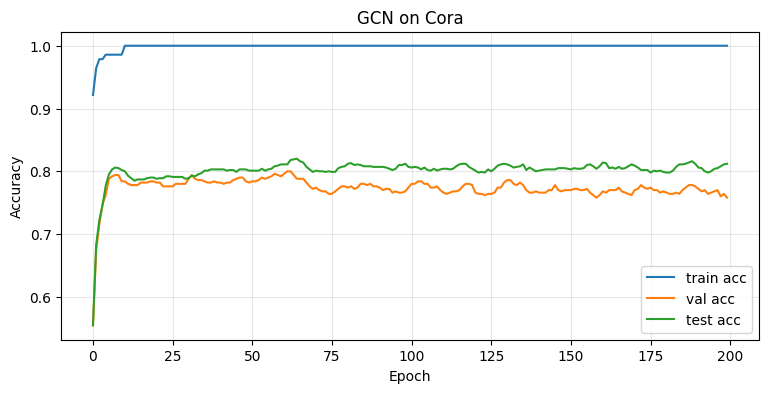

In [5]:
plt.figure(figsize=(9, 4))
for k, c in [('train', 'C0'), ('val', 'C1'), ('test', 'C2')]:
    plt.plot(hist[k], label=f'{k} acc', color=c)
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('GCN on Cora')
plt.legend(); plt.grid(alpha=0.3); plt.show()


### How to Read This Chart: GCN Training Curves

Train, validation, and test accuracy per epoch.

- **Train accuracy** climbs toward 1.0 quickly — only 140 nodes, easy to fit.
- **Validation / test** are the honest numbers, measured on nodes the model never trained on. A well-tuned GCN reaches **~80% test accuracy** on Cora.
- Getting 80% of papers right from **only 140 labels** (5% of the graph) is the headline: the citation structure did most of the work, spreading label information across edges.


---


## Section 6 — Does the Graph Actually Help?

The cleanest way to prove the graph matters: train a plain **MLP** on the exact same node features but with **no edges at all** (this is essentially notebook 01's model applied here). If the graph is informative, the GCN should clearly beat it.


MLP  (features only, no graph): 0.566
GCN  (features + citations)   : 0.812
Improvement from using the graph: +0.246


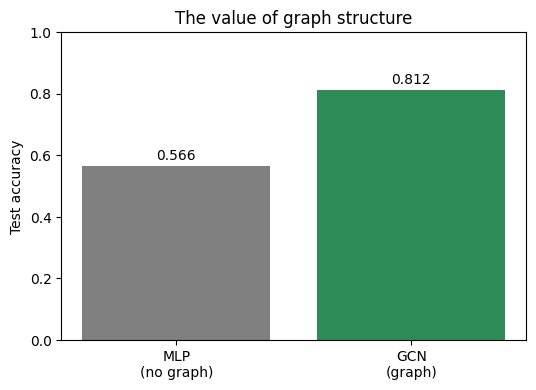

In [6]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, n_classes, dropout=0.5):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, n_classes)
        self.dropout = dropout
    def forward(self, x):
        h = F.dropout(F.relu(self.fc1(x)), p=self.dropout, training=self.training)
        return self.fc2(h)

mlp = MLP(dataset.num_node_features, 64, dataset.num_classes).to(device)
opt = torch.optim.Adam(mlp.parameters(), lr=0.01, weight_decay=5e-4)
for epoch in range(200):
    mlp.train(); opt.zero_grad()
    out = mlp(data.x)
    F.cross_entropy(out[data.train_mask], data.y[data.train_mask]).backward(); opt.step()
mlp.eval()
with torch.no_grad():
    mlp_test = (mlp(data.x).argmax(1)[data.test_mask] == data.y[data.test_mask]).float().mean().item()

print(f"MLP  (features only, no graph): {mlp_test:.3f}")
print(f"GCN  (features + citations)   : {hist['test'][-1]:.3f}")
print(f"Improvement from using the graph: {hist['test'][-1]-mlp_test:+.3f}")

plt.figure(figsize=(6, 4))
plt.bar(['MLP\n(no graph)', 'GCN\n(graph)'], [mlp_test, hist['test'][-1]],
        color=['gray', 'seagreen'])
plt.ylabel('Test accuracy'); plt.title('The value of graph structure'); plt.ylim(0, 1)
for i, v in enumerate([mlp_test, hist['test'][-1]]):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.show()


### How to Read This Chart: GCN vs MLP

Both models see the **same 1,433-dim features** and the **same 140 training labels**. The only difference: the GCN also sees the citation edges, the MLP doesn't.

The GCN's higher bar is the entire argument for graph neural networks — the gap is pure value extracted from **relationships between data points**, something a per-sample model structurally cannot use. When your data has meaningful connections, ignoring them (as every earlier notebook's architecture would) leaves accuracy on the table.


---


## Section 7 — Embedding Visualization

Finally, we project the GCN's learned hidden embeddings (64-dim) down to 2D with t-SNE and color each point by its true topic. If the model learned well, papers of the same topic should cluster.


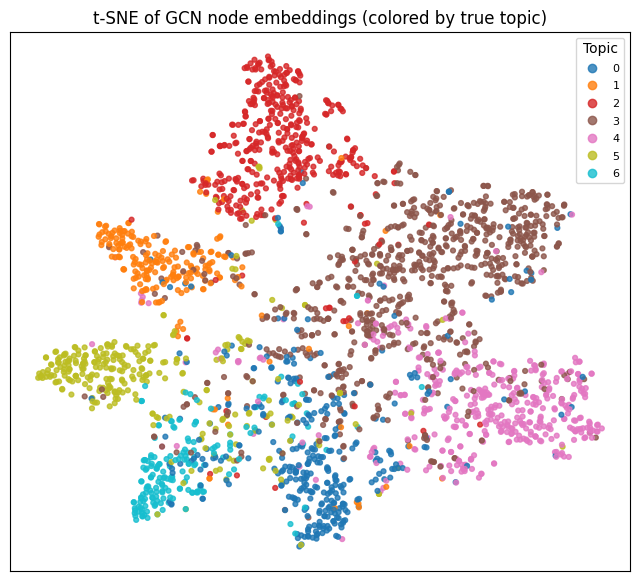

In [7]:
from sklearn.manifold import TSNE

model.eval()
with torch.no_grad():
    _, embed = model(data.x, data.edge_index, return_embed=True)
emb2d = TSNE(n_components=2, init='pca', perplexity=30, random_state=42).fit_transform(embed.cpu().numpy())

plt.figure(figsize=(8, 7))
scatter = plt.scatter(emb2d[:, 0], emb2d[:, 1], c=data.y.cpu().numpy(),
                      cmap='tab10', s=12, alpha=0.8)
plt.legend(*scatter.legend_elements(), title='Topic', loc='best', fontsize=8)
plt.title('t-SNE of GCN node embeddings (colored by true topic)')
plt.xticks([]); plt.yticks([]); plt.show()


### How to Read This Chart: Node Embeddings

Each point is a paper, positioned by t-SNE so that papers with similar learned embeddings sit close together, and colored by its true topic.

- **Well-separated colored clusters** mean the GCN learned representations where topic is easy to read off — even though it was trained on only 140 labels.
- **Overlapping regions** are papers whose citation neighborhoods span multiple topics (interdisciplinary papers) — genuinely hard cases.

This is the graph analog of notebook 01's autoencoder latent-space PCA and notebook 05's VAE latent scatter: in all three, a good model organizes its internal space so that semantically similar inputs land together.


---


## Key Takeaways

1. **Graphs are a data type earlier architectures can't handle** — no fixed grid, no ordering, variable size.
2. **Message passing is the core operation:** each node aggregates its neighbors, repeatedly.
3. **Two GCN layers = a 2-hop receptive field** — a node's prediction uses its neighbors' neighbors.
4. **The graph carries real signal:** the GCN beats a feature-only MLP by a wide margin on Cora.
5. **GNNs power** recommendation systems, fraud detection, molecular property prediction, and traffic forecasting — anywhere relationships matter as much as the entities themselves.

---

## Series Wrap-Up

Across eight notebooks you've now built the full modern deep-learning toolkit:

| Data shape | Architecture | Notebook |
|---|---|---|
| Flat vectors | MLP / Autoencoder | 01 |
| Grids (images) | CNN | 02 |
| Sequences | RNN / LSTM / GRU | 03 |
| Sequences (attention) | Transformer / BERT | 04 |
| — (generation) | VAE / GAN | 05 |
| — (generation) | Diffusion | 06 |
| Grids (as patches) | Vision Transformer | 07 |
| Graphs | GCN | 08 |

Every one is interactive in the companion web demo.
